# **Kaggle Competition**

### SP24 TAMU-CSCE-633-600: Machine Learning



Given the input data, your model will predict the corresponding digit (the probability that that sample is digit 0 - 9):

* The provided dataset is multimodal. We have written digits as images and
the corresponding audio. The images in this homework are the same ones you worked with in HW4.
* Create two encoder models, one for the image dataset and one for the audio dataset.
* In this HW - you will be using audio as an extra data stream. You can try different methods to fuse these two data modalities.
* After training, save the embedding of the encoder for both image and audio.
* Use dimensionality reduction methods like TSNE to visualize the embedding of the training data in a 2-dimensional space. Color code each point by the corresponding label. Apply kmeans clustering with k = 10. Did the model extract clusters associated with the digit labels? Compare the clustering result of audio and image embedding. Explain your observation.
*  With your trained model, you will make a prediction using the test data (x_test_wr.csv and x_test_sp.csv). You will save the probabilities along in a CSV submission file. The file should contain two columns: - The main column will have ***Digit_Probability*** as the header and will contain the predicted label.

In [1]:
import numpy as np
import pandas as pd
import keras
from keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Dense, Flatten, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import homogeneity_score
from keras.regularizers import l2
from keras.layers import Conv2D, MaxPooling2D, Flatten
from keras.layers import Dropout
from keras.layers import Reshape

x_train_wr = np.load('x_train_wr.npy')
x_train_sp = np.load('x_train_sp.npy')
x_test_wr = np.load('x_test_wr.npy')
x_test_sp = np.load('x_test_sp.npy')
y_train = pd.read_csv('y_train.csv')


This code snippet loads numpy arrays (`x_train_wr`, `x_train_sp`, `x_test_wr`, `x_test_sp`) containing image and audio data, as well as a Pandas DataFrame (`y_train`) containing labels. It imports necessary libraries for building a neural network model using Keras and TensorFlow. The data is loaded from files (`x_train_wr.npy`, `x_train_sp.npy`, `x_test_wr.npy`, `x_test_sp.npy`, `y_train.csv`). The data is then prepared for training by splitting it into training and testing sets. The code sets up the environment for training and evaluating a neural network model for a multimodal classification task using image and audio data.

In [2]:
image_test = x_test_wr.reshape(-1, 28, 28)
audio_test = x_test_sp.reshape(-1, 507)
x_train_wr_reshaped = x_train_wr.reshape(-1, 28, 28)
x_train_sp_reshaped = x_train_sp.reshape(-1, 507)

image_train, image_val, audio_train, audio_val, labels_train, labels_val = train_test_split(x_train_wr_reshaped, x_train_sp_reshaped, y_train, test_size=0.2, random_state=42)


Data Pre-processing:

In the above code, the train and test data for image and audio are reshaped for fitting into the image and audio encoders respectively. Next, this train data and *y_train* data is split in the ratio 80:20 (training:validation).

In [3]:
# Define image encoder
image_input = Input(shape=(28, 28))
image_flatten = Flatten()(image_input)
image_encoder_output = Dense(64, activation='relu')(image_flatten)
image_encoder = Model(image_input, image_encoder_output)

# Define audio encoder
audio_input = Input(shape=(507,))
audio_encoder_output = Dense(64, activation='relu')(audio_input)
audio_encoder = Model(audio_input, audio_encoder_output)

The above code defines two encoder models: one for processing image data and another for audio data. Both encoders consist of a single dense layer with 64 units and ReLU activation. The image encoder takes inputs of shape (28, 28), flattens them, and passes them through the dense layer. The audio encoder directly processes inputs of shape (507) through the dense layer.

In [4]:
image_embeddings = image_encoder.predict(image_train)
audio_embeddings = audio_encoder.predict(audio_train)
np.save('image_embeddings.npy', image_embeddings)
np.save('audio_embeddings.npy', audio_embeddings)


1500/1500 [==============================] - 3s 2ms/step


This above code snippet seems to be using an image encoder and an audio encoder to generate embeddings for image and audio data, respectively. Then, it saves these embeddings into numpy arrays named 'image_embeddings.npy' and 'audio_embeddings.npy'.

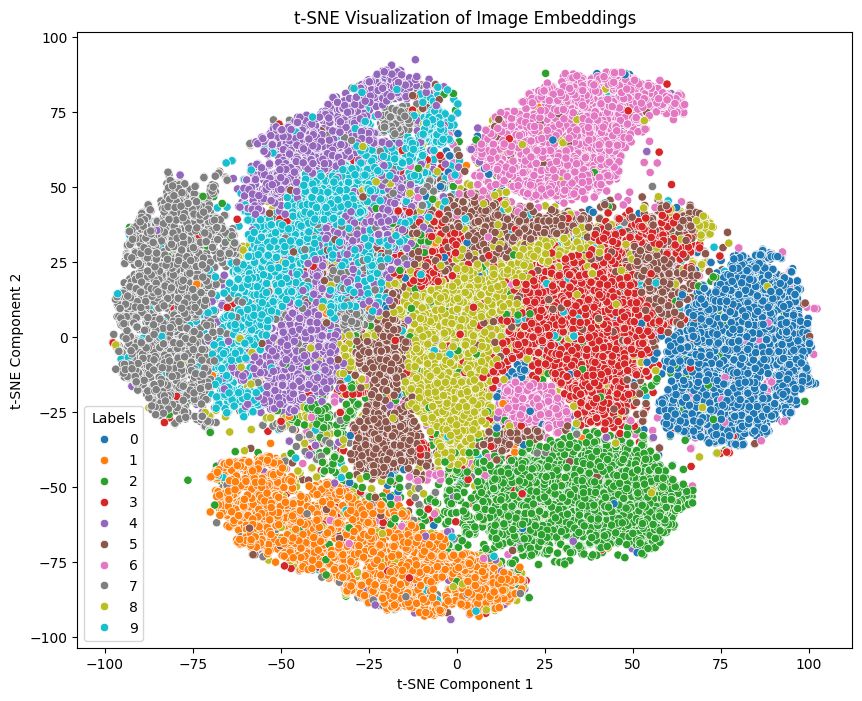

In [5]:
tsne = TSNE(n_components=2, random_state=42)
image_embeddings_tsne = tsne.fit_transform(image_embeddings)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=image_embeddings_tsne[:, 0], y=image_embeddings_tsne[:, 1], hue=labels_train['label'], palette='tab10')
plt.title('t-SNE Visualization of Image Embeddings')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Labels')
plt.show()

This code performs t-SNE dimensionality reduction on image embeddings, visualizing them in a scatter plot colored by their corresponding labels. It reduces the embeddings to 2 dimensions for visualization.

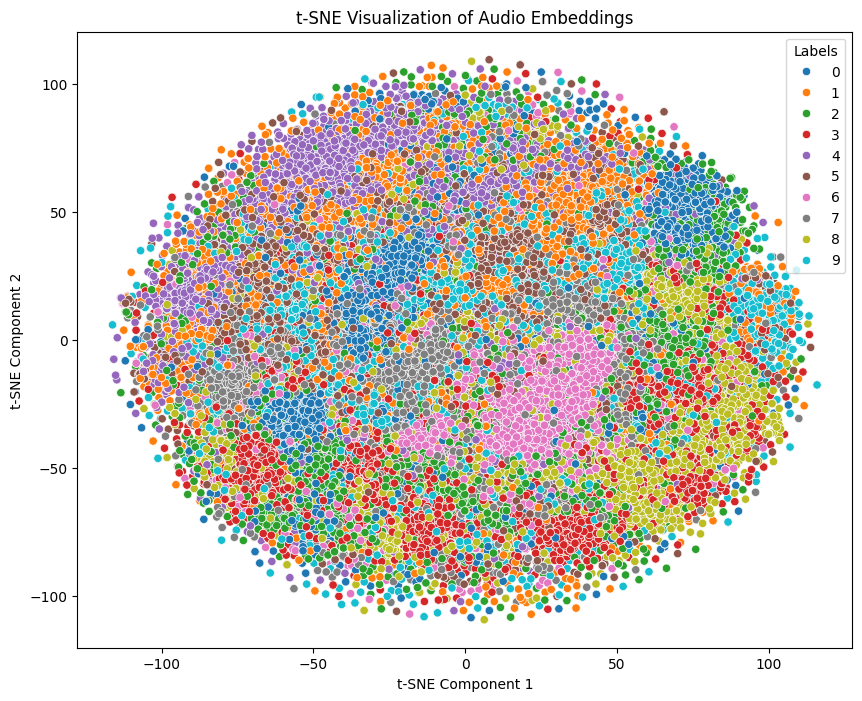

In [6]:
audio_embeddings_tsne = tsne.fit_transform(audio_embeddings)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=audio_embeddings_tsne[:, 0], y=audio_embeddings_tsne[:, 1], hue=labels_train['label'], palette='tab10')
plt.title('t-SNE Visualization of Audio Embeddings')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Labels')
plt.show()


This above code snippet performs t-SNE dimensionality reduction on audio embeddings, then visualizes them in a scatter plot colored by labels.

In [7]:
kmeans_img = KMeans(n_clusters=10, random_state=42)
img_clusters = kmeans_img.fit_predict(image_embeddings)

kmeans_audio = KMeans(n_clusters=10, random_state=42)
audio_clusters = kmeans_audio.fit_predict(audio_embeddings)

print("Clustering result for image embeddings:")
print(img_clusters)
print("\nClustering result for audio embeddings:")
print(audio_clusters,"\n")

homogeneity_img = homogeneity_score(labels_train['label'], img_clusters)
homogeneity_audio = homogeneity_score(labels_train['label'], audio_clusters)
print(f"Homogeneity score for Image clustering:",homogeneity_img)
print(f"Homogeneity score for Audio clustering:",homogeneity_audio)


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Clustering result for image embeddings:
[2 7 7 ... 0 0 0]

Clustering result for audio embeddings:
[0 6 3 ... 9 9 3] 

Homogeneity score for Image clustering: 0.29573251364766184
Homogeneity score for Audio clustering: 0.1462980922483002


This code snippet performs clustering on image and audio embeddings using KMeans. It then calculates and prints the clustering results and homogeneity scores for both image and audio clusters. The homogeneity score measures the degree to which clusters contain only data points from a single class.

**Explanation (k-Means)**:
The homogeneity score for image clustering is 0.296, indicating that the clusters formed by the image embeddings are somewhat accurate in visualizing the labels. Meaning that most of the data points are in their accurate cluster (label), which is not the same case in audio clustering due to its lower homogeneity score.  The higher the homogeneity score the better the clustering.

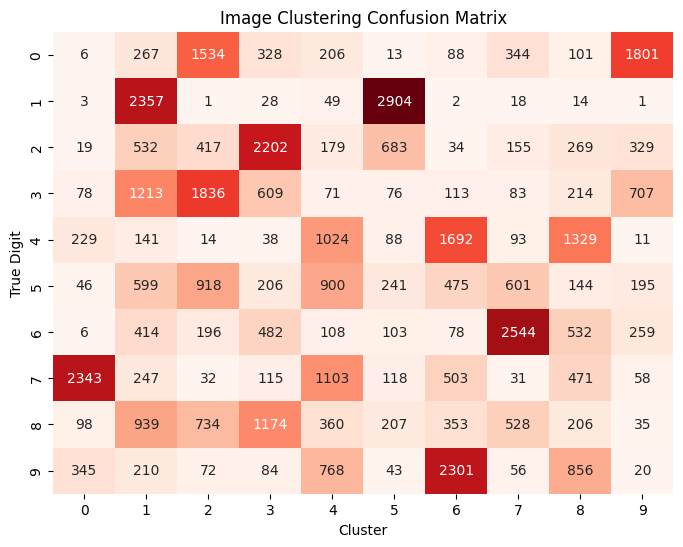

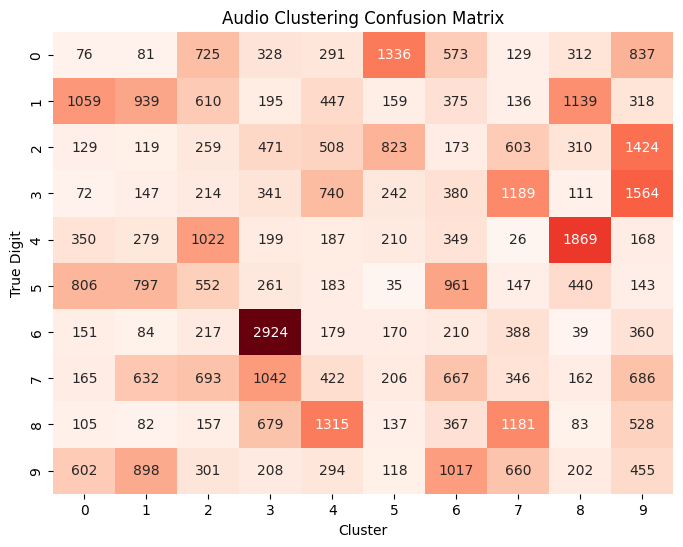

In [8]:
img_conf_matrix = confusion_matrix(labels_train['label'], img_clusters)
audio_conf_matrix = confusion_matrix(labels_train['label'], audio_clusters)

plt.figure(figsize=(8, 6))
sns.heatmap(img_conf_matrix, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Image Clustering Confusion Matrix')
plt.xlabel('Cluster')
plt.ylabel('True Digit')
plt.show()


plt.figure(figsize=(8, 6))
sns.heatmap(audio_conf_matrix, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Audio Clustering Confusion Matrix')
plt.xlabel('Cluster')
plt.ylabel('True Digit')
plt.show()


This above code generates confusion matrices for image and audio clustering results, then visualizes them using seaborn's heatmap.

**Explanation (k-means clustering):**

From the above confusion matrices, there is diagonal dominance in case of Image embeddings k-means clustering 's comfusion matrix as compared to the audio embeddings confusion matrix (that is, the majority of entries along the diagonal are higher than those off the diagonal).

**k-means clustering (final explanation):**

Based on confusion matrix and the homogeneity score, we can say that the k-means clustering on Image embeddings is better than audio embeddings.

In [9]:
combined_encoder_output = Concatenate()([image_encoder_output, audio_encoder_output])
combined_encoder = Model([image_input, audio_input], combined_encoder_output)
x = Dense(128, activation='relu')(combined_encoder_output)
x = Dense(64, activation='relu')(x)
classification_output = Dense(10, activation='softmax')(x)
combined_model = Model([image_input, audio_input], classification_output)

The above code creates a neural network model that combines image and audio inputs for classification. It concatenates the outputs of separate encoders for images and audio, processes them through two dense layers with ReLU activation, and outputs classification probabilities for 10 classes using softmax activation. In essence, it integrates visual and auditory information to make predictions about input data's class labels.

In [10]:
learning_rates = [0.01, 0.001]
batch_sizes = [32, 64]
optimizers = ['Adam', 'SGD']

best_val_accuracy = 0
best_hyperparameters = {}

for lr in learning_rates:
    for batch_size_value in batch_sizes:
        for optimizer_name in optimizers:
            print("Learning rate:", lr, ", Batch size:", batch_size_value, ", Optimizer:", optimizer_name)

            if optimizer_name == 'Adam':
                optimizer = keras.optimizers.Adam(lr)
            elif optimizer_name == 'RMSprop':
                optimizer = keras.optimizers.RMSprop(lr)
            elif optimizer_name == 'SGD':
                optimizer = keras.optimizers.SGD(lr)

            combined_model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

            history = combined_model.fit(
                [image_train, audio_train],
                labels_train['label'],
                epochs=10,
                batch_size=batch_size_value,
                validation_data=([image_val, audio_val], labels_val['label'])
            )

            val_accuracy = history.history['val_accuracy'][-1]

            if val_accuracy > best_val_accuracy:
                best_val_accuracy = val_accuracy
                best_hyperparameters = {
                    'learning_rate': lr,
                    'batch_size': batch_size_value,
                    'optimizer': optimizer_name
                }

print("Best Hyperparameters:")
print(best_hyperparameters)

Learning rate: 0.01 , Batch size: 32 , Optimizer: Adam
Epoch 1/10
1500/1500 [==============================] - 8s 5ms/step - loss: 0.3385 - accuracy: 0.9020 - val_loss: 0.2874 - val_accuracy: 0.9122
Epoch 2/10
1500/1500 [==============================] - 9s 6ms/step - loss: 0.2150 - accuracy: 0.9432 - val_loss: 0.2653 - val_accuracy: 0.9342
Epoch 3/10
1500/1500 [==============================] - 7s 5ms/step - loss: 0.1916 - accuracy: 0.9507 - val_loss: 0.2234 - val_accuracy: 0.9420
Epoch 4/10
1500/1500 [==============================] - 7s 5ms/step - loss: 0.1736 - accuracy: 0.9554 - val_loss: 0.2144 - val_accuracy: 0.9473
Epoch 5/10
1500/1500 [==============================] - 8s 5ms/step - loss: 0.1662 - accuracy: 0.9600 - val_loss: 0.1975 - val_accuracy: 0.9542
Epoch 6/10
1500/1500 [==============================] - 7s 5ms/step - loss: 0.1469 - accuracy: 0.9637 - val_loss: 0.2160 - val_accuracy: 0.9532
Epoch 7/10
1500/1500 [==============================] - 9s 6ms/step - loss: 0.147

This above code snippet is an implementation of a grid search algorithm which is used to identify the optimal combination of hyperparameters for a combined model trained on both image and audio data. It  explores various values for learning rates, batch sizes, and optimizers by iterating through nested loops. For each combination of hyperparameters, the code compiles the model using the specified optimizer, categorical cross-entropy loss function, and accuracy metric. It then trains the model on the training data for a fixed number of epochs and evaluates its performance on the validation set. The validation accuracy achieved with each set of hyperparameters is tracked, and if a new best validation accuracy is obtained, the corresponding hyperparameters are recorded. Once all combinations have been evaluated, the code outputs the best hyperparameters found. Overall, this approach enables the systematic exploration of hyperparameter space to identify the configuration that maximizes model performance.


In [11]:
best_learning_rate = best_hyperparameters['learning_rate']
best_batch_size = best_hyperparameters['batch_size']
best_optimizer_name = best_hyperparameters['optimizer']
print("Best learning rate:", best_learning_rate, ", Best batch size:", best_batch_size, ", Best optimizer:", best_optimizer_name)
best_combined_encoder_output = Concatenate()([image_encoder_output, audio_encoder_output])
x1 = Dense(128, activation='relu')(best_combined_encoder_output)
x1 = Dense(64, activation='relu')(x1)
best_classification_output = Dense(10, activation='softmax')(x1)
best_combined_model = Model([image_input, audio_input], best_classification_output)

if best_optimizer_name == 'Adam':
    best_optimizer = keras.optimizers.Adam(lr=best_learning_rate)
elif best_optimizer_name == 'SGD':
    best_optimizer = keras.optimizers.SGD(lr=best_learning_rate)

best_combined_model.compile(optimizer=best_optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

best_combined_model.fit(
    [image_train, audio_train],
    labels_train['label'],
    epochs=10,
    batch_size=best_batch_size,
    validation_data=([image_val, audio_val], labels_val['label'])
)


Best learning rate: 0.001 , Best batch size: 32 , Best optimizer: SGD
Epoch 1/10
1500/1500 [==============================] - 7s 4ms/step - loss: 0.1216 - accuracy: 0.9677 - val_loss: 0.1440 - val_accuracy: 0.9596
Epoch 2/10
1500/1500 [==============================] - 7s 5ms/step - loss: 0.0514 - accuracy: 0.9860 - val_loss: 0.1391 - val_accuracy: 0.9629
Epoch 3/10
1500/1500 [==============================] - 8s 6ms/step - loss: 0.0421 - accuracy: 0.9885 - val_loss: 0.1419 - val_accuracy: 0.9638
Epoch 4/10
1500/1500 [==============================] - 7s 5ms/step - loss: 0.0369 - accuracy: 0.9902 - val_loss: 0.1362 - val_accuracy: 0.9649
Epoch 5/10
1500/1500 [==============================] - 7s 5ms/step - loss: 0.0333 - accuracy: 0.9909 - val_loss: 0.1388 - val_accuracy: 0.9651
Epoch 6/10
1500/1500 [==============================] - 7s 5ms/step - loss: 0.0302 - accuracy: 0.9918 - val_loss: 0.1454 - val_accuracy: 0.9647
Epoch 7/10
1500/1500 [==============================] - 8s 5ms/ste

This code segment identifies the best hyperparameters (**learning rate = 0.001, batch size = 32,** and **optimizer = SGD**) obtained from a grid search. It then constructs a combined model for image and audio data fusion, based on the best hyperparameters. The model architecture includes concatenating the outputs of image and audio encoders, followed by dense layers for classification. Depending on the chosen optimizer (SGD), the appropriate optimizer, that is, **SGD **instance is created with the best learning rate. The model is compiled with sparse categorical cross-entropy loss and accuracy metrics. Finally, the model is trained using the training data, with validation performed on the validation data for 10 epochs.

In [12]:
predicted_labels = best_combined_model.predict([image_test, audio_test])

submission_df = pd.DataFrame({'row_id': range(len(predicted_labels)), 'Digit_Probability': predicted_labels.argmax(axis=1)})
submission_df.to_csv('Jnana_Preeti_Parlapalli_preds.csv', index=False)


313/313 [==============================] - 1s 2ms/step


This code segment uses the trained combined model to predict labels for the test data, which consists of both image and audio samples. The `predict` method of the model is used to obtain the predicted probabilities for each digit label. These probabilities are then converted into predicted labels by selecting the index of the highest probability. The predicted labels are stored in a DataFrame along with a row identifier. Finally, the DataFrame is saved as a CSV file named 'Jnana_Preeti_Parlapalli_preds.csv'. This CSV file serves as the submission file for the predicted digit labels.